In [ ]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [ ]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
go_dna = np.load( path + 'go_dna_dataset.npz')

In [3]:
investigate_dataset(go_dna)

['X', 'y', 'genes']

Array shapes:
X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3

X dimensions: 3
X first sample shape: (12288, 6)
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(go_dna['X'], go_dna['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (3697, 2048)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 88.04%


In [ ]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, go_dna['genes'])
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997223,-3.263668,6.096068,2.878462,2.100506,4.996912,3.763525,-2.090918,4.035164,...,0.633351,2.110667,0.065447,0.162702,-0.017556,0.009416,0.567895,-0.160698,0.707824,-0.868611
FGR,-9.459958,17.357185,-2.683482,-1.475222,5.934569,0.881406,4.911112,-0.139806,5.210955,2.031818,...,1.467558,-1.225297,0.729028,0.097486,-0.957057,0.647059,-0.006628,-1.004903,0.020957,-0.376857
CFH,8.703367,23.714615,-4.040096,9.490229,-7.428895,3.553716,-0.899185,-2.731736,-10.456056,5.410211,...,-0.048656,-0.303484,-0.195511,0.639711,-0.801864,0.247087,-1.591953,-0.765399,1.219610,-0.841123
NFYA,15.312553,-8.760534,-8.302439,0.726783,-4.641912,-10.267216,-7.944340,3.541776,4.940775,-1.913150,...,-0.095914,-0.258079,-0.004476,-0.468509,0.793039,-0.673015,0.165602,-0.072394,-0.274135,0.640693
CFTR,20.702240,-18.581966,-19.757910,0.525849,8.217774,4.778090,-9.160920,-4.210214,-1.545769,9.986914,...,-0.328865,0.266220,0.207960,0.101534,0.241998,-0.680695,0.097508,0.109997,-0.184851,0.114298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407379,5.946151,-1.468842,-10.506931,5.137068,-4.193423,-4.807705,-5.273265,-5.704327,-1.174060,...,0.037179,-0.003740,0.139308,-0.076307,0.242455,-0.128020,0.127398,0.063528,-0.378171,0.355470
CPHXL2,-14.601645,-6.739914,-9.937515,-7.373091,-5.922986,-6.634362,-1.230134,-2.815758,-2.358856,-0.869955,...,-0.022460,-0.272499,0.293423,0.601295,-0.690675,-0.568075,-0.530292,-0.490961,0.675695,0.878187
C8orf44-SGK3,-2.840679,14.210383,-2.690830,6.343120,0.053429,2.255766,3.574268,5.975232,-1.967725,2.915293,...,0.128375,-0.666663,-0.772436,-0.274406,-0.058645,-1.354810,0.653214,-0.012676,0.447747,0.061615


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997223,-3.263668,6.096068,2.878462,2.100506,4.996912,3.763525,-2.090918,4.035164,...,0.633351,2.110667,0.065447,0.162702,-0.017556,0.009416,0.567895,-0.160698,0.707824,-0.868611
FGR,-9.459958,17.357185,-2.683482,-1.475222,5.934569,0.881406,4.911112,-0.139806,5.210955,2.031818,...,1.467558,-1.225297,0.729028,0.097486,-0.957057,0.647059,-0.006628,-1.004903,0.020957,-0.376857
CFH,8.703367,23.714615,-4.040096,9.490229,-7.428895,3.553716,-0.899185,-2.731736,-10.456056,5.410211,...,-0.048656,-0.303484,-0.195511,0.639711,-0.801864,0.247087,-1.591953,-0.765399,1.219610,-0.841123
NFYA,15.312553,-8.760534,-8.302439,0.726783,-4.641912,-10.267216,-7.944340,3.541776,4.940775,-1.913150,...,-0.095914,-0.258079,-0.004476,-0.468509,0.793039,-0.673015,0.165602,-0.072394,-0.274135,0.640693
CFTR,20.702240,-18.581966,-19.757910,0.525849,8.217774,4.778090,-9.160920,-4.210214,-1.545769,9.986914,...,-0.328865,0.266220,0.207960,0.101534,0.241998,-0.680695,0.097508,0.109997,-0.184851,0.114298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407379,5.946151,-1.468842,-10.506931,5.137068,-4.193423,-4.807705,-5.273265,-5.704327,-1.174060,...,0.037179,-0.003740,0.139308,-0.076307,0.242455,-0.128020,0.127398,0.063528,-0.378171,0.355470
CPHXL2,-14.601645,-6.739914,-9.937515,-7.373091,-5.922986,-6.634362,-1.230134,-2.815758,-2.358856,-0.869955,...,-0.022460,-0.272499,0.293423,0.601295,-0.690675,-0.568075,-0.530292,-0.490961,0.675695,0.878187
C8orf44-SGK3,-2.840679,14.210383,-2.690830,6.343120,0.053429,2.255766,3.574268,5.975232,-1.967725,2.915293,...,0.128375,-0.666663,-0.772436,-0.274406,-0.058645,-1.354810,0.653214,-0.012676,0.447747,0.061615


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997223,-3.263668,6.096068,2.878462,2.100506,4.996912,3.763525,-2.090918,4.035164,...,-0.017556,0.009416,0.567895,-0.160698,0.707824,-0.868611,False,False,False,False
FGR,-9.459958,17.357185,-2.683482,-1.475222,5.934569,0.881406,4.911112,-0.139806,5.210955,2.031818,...,-0.957057,0.647059,-0.006628,-1.004903,0.020957,-0.376857,False,False,False,False
CFH,8.703367,23.714615,-4.040096,9.490229,-7.428895,3.553716,-0.899185,-2.731736,-10.456056,5.410211,...,-0.801864,0.247087,-1.591953,-0.765399,1.219610,-0.841123,False,False,False,False
NFYA,15.312553,-8.760534,-8.302439,0.726783,-4.641912,-10.267216,-7.944340,3.541776,4.940775,-1.913150,...,0.793039,-0.673015,0.165602,-0.072394,-0.274135,0.640693,False,False,False,False
CFTR,20.702240,-18.581966,-19.757910,0.525849,8.217774,4.778090,-9.160920,-4.210214,-1.545769,9.986914,...,0.241998,-0.680695,0.097508,0.109997,-0.184851,0.114298,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL3,-15.490881,-0.406340,-2.594774,-9.861944,-1.599639,-4.762671,-4.898744,-4.700263,-5.546362,-3.239730,...,-0.343049,-0.169156,-0.289352,-0.389099,0.539130,-0.118374,False,False,False,False
SSTR3,4.326692,-5.663827,12.208854,9.123994,1.093344,0.461763,1.553366,-4.534101,-0.840324,-7.031982,...,0.032389,-0.486650,0.090658,0.854483,0.998894,-1.589279,False,False,False,False
MYO19,5.753082,-14.638531,-17.008068,9.437117,5.492753,7.279840,1.104508,-5.904288,-3.853732,0.653596,...,-1.050670,0.088016,0.615520,-0.768221,-0.224782,-0.601912,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    2956
True      313
Name: count, dtype: int64

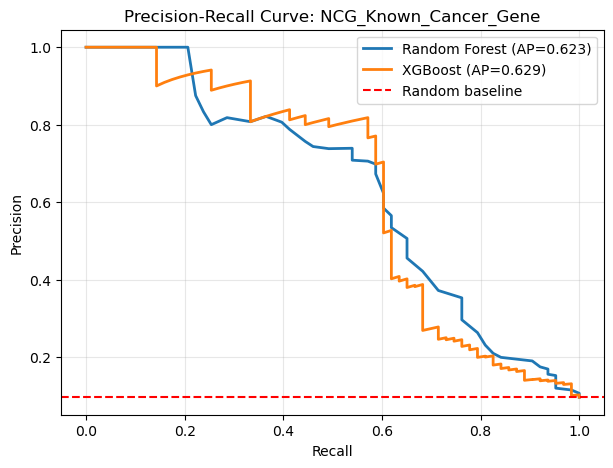

Random Forest - auPRC: 0.623
XGBoost - auPRC: 0.629



In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    2899
True      370
Name: count, dtype: int64

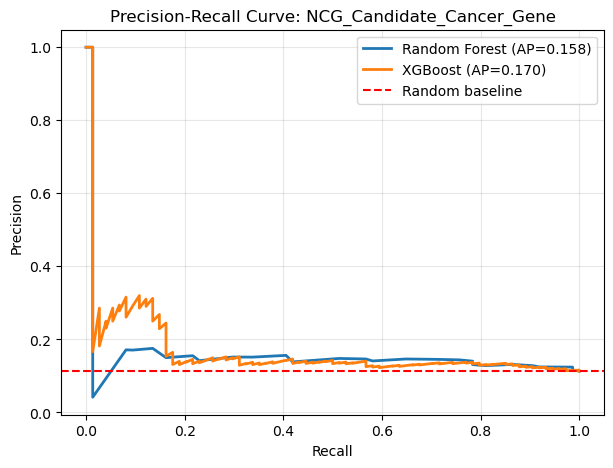

Random Forest - auPRC: 0.158
XGBoost - auPRC: 0.170



In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    3016
True      253
Name: count, dtype: int64

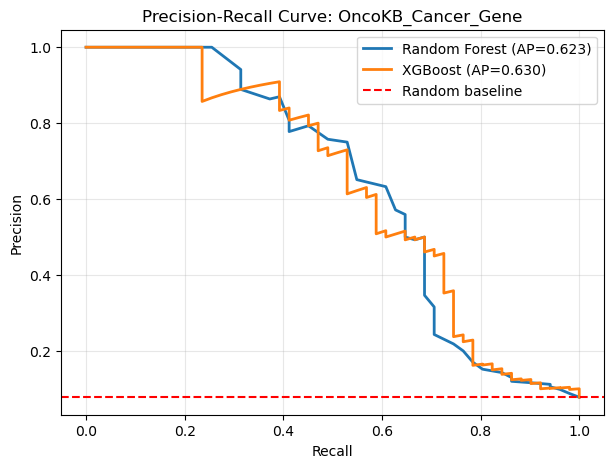

Random Forest - auPRC: 0.623
XGBoost - auPRC: 0.630



In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    3134
True      135
Name: count, dtype: int64

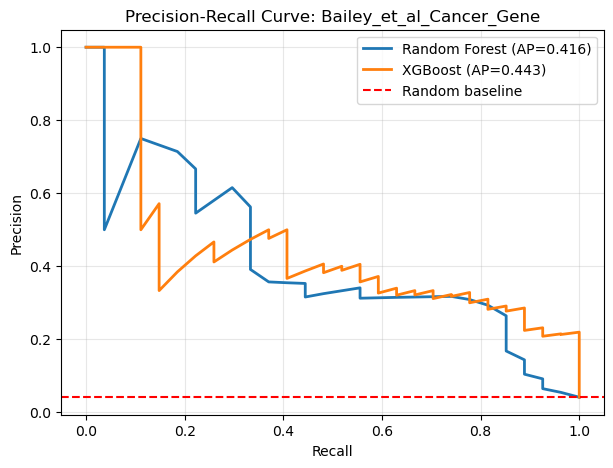

Random Forest - auPRC: 0.416
XGBoost - auPRC: 0.443



In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')